#**Text Classification with Representation Models**



##**Using a Task-Specific Model**

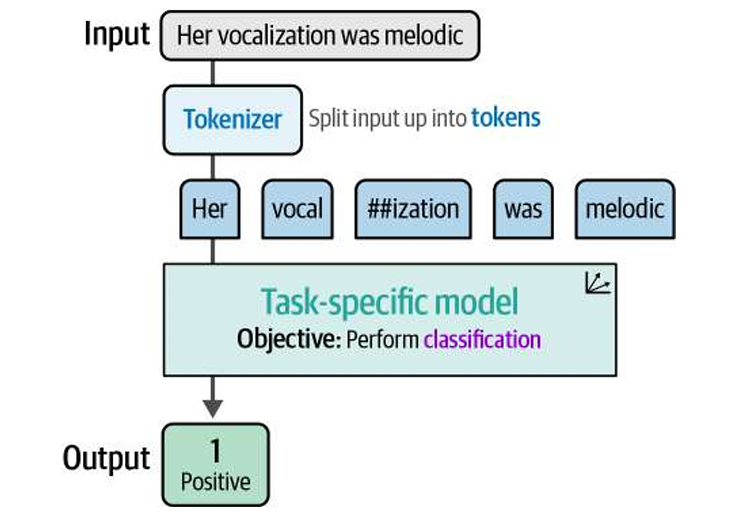

In [1]:
from datasets import load_dataset
data = load_dataset("cornell-movie-review-data/rotten_tomatoes")
data

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 8530
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 1066
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 1066
    })
})

In [2]:
data["train"][0,-1]

{'text': ['the rock is destined to be the 21st century\'s new " conan " and that he\'s going to make a splash even greater than arnold schwarzenegger , jean-claud van damme or steven segal .',
  'things really get weird , though not particularly scary : the movie is all portent and no content .'],
 'label': [1, 0]}

In [3]:
import torch

print(torch.cuda.is_available())
print(torch.__version__)

True
2.11.0+cu128


In [4]:
from transformers import pipeline

# Path to our HF model
model_path = "cardiffnlp/twitter-roberta-base-sentiment-latest"

# Load model into pipeline
pipe = pipeline(
    model=model_path,
    tokenizer=model_path,
    return_all_scores=True,
    device="cuda:0"   # Use GPU
)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                         | Status     |  | 
----------------------------+------------+--+-
roberta.pooler.dense.weight | UNEXPECTED |  | 
roberta.pooler.dense.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [5]:
sample = next(iter(pipe(["I love this movie!"])))
print(sample)

{'label': 'positive', 'score': 0.9847092628479004}


In [6]:
import numpy as np
from tqdm import tqdm
from transformers.pipelines.pt_utils import KeyDataset

y_pred = []

for output in tqdm(
    pipe(KeyDataset(data["test"], "text")),
    total=len(data["test"])
):
    label = output["label"].lower()

    if "negative" in label:
        y_pred.append(0)
    elif "positive" in label:
        y_pred.append(1)
    else:  # neutral
        y_pred.append(2)

100%|██████████| 1066/1066 [00:30<00:00, 34.51it/s]


In [7]:
from sklearn.metrics import classification_report

def evaluate_performance(y_true, y_pred):
    performance = classification_report(
        y_true,
        y_pred,
        labels=[0, 1, 2],
        target_names=["Negative Review", "Neutral Review", "Positive Review"],
        zero_division=0
    )
    print(performance)

evaluate_performance(data["test"]["label"], y_pred)

                 precision    recall  f1-score   support

Negative Review       0.81      0.69      0.75       533
 Neutral Review       0.91      0.56      0.69       533
Positive Review       0.00      0.00      0.00         0

       accuracy                           0.63      1066
      macro avg       0.57      0.42      0.48      1066
   weighted avg       0.86      0.63      0.72      1066



##**Classification Tasks That Leverage Embeddings**

This is a two -step process. In this approach, the SentenceTransformer (all-mpnet-base-v2) converts each text review into a numerical embedding (vector) that captures its semantic meaning. These embeddings are then used to train a Logistic Regression classifier, which learns patterns from the training data and predicts whether new reviews are negative or positive based on their vector representations.

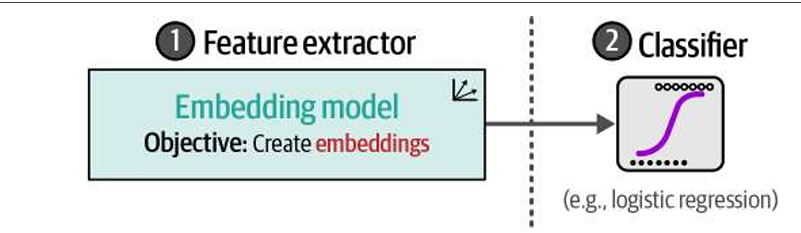

In [8]:
from sentence_transformers import SentenceTransformer

# Load model
model = SentenceTransformer("sentence-transformers/all-mpnet-base-v2")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

In [9]:
# Convert text to embeddings
train_embeddings = model.encode(
    data["train"]["text"],
    show_progress_bar=True
)

test_embeddings = model.encode(
    data["test"]["text"],
    show_progress_bar=True
)

Batches:   0%|          | 0/267 [00:00<?, ?it/s]

Batches:   0%|          | 0/34 [00:00<?, ?it/s]

In [10]:
from sklearn.metrics import classification_report

def evaluate_performance(y_true, y_pred):
    performance = classification_report(
        y_true,
        y_pred,
        labels=[0, 1],
        target_names=["Negative Review", "Positive Review"],
        zero_division=0
    )
    print(performance)

In [11]:
from sklearn.linear_model import LogisticRegression

# Train a logistic regression on our train embeddings
clf = LogisticRegression(
    random_state=42,
    max_iter=1000
)

clf.fit(
    train_embeddings,
    data["train"]["label"]
)

LogisticRegression(max_iter=1000, random_state=42)

In [12]:
# Predict previously unseen instances
y_pred = clf.predict(test_embeddings)

evaluate_performance(
    data["test"]["label"],
    y_pred
)

                 precision    recall  f1-score   support

Negative Review       0.85      0.86      0.85       533
Positive Review       0.86      0.85      0.85       533

       accuracy                           0.85      1066
      macro avg       0.85      0.85      0.85      1066
   weighted avg       0.85      0.85      0.85      1066



##**What If We Do Not Have Labeled Data?**

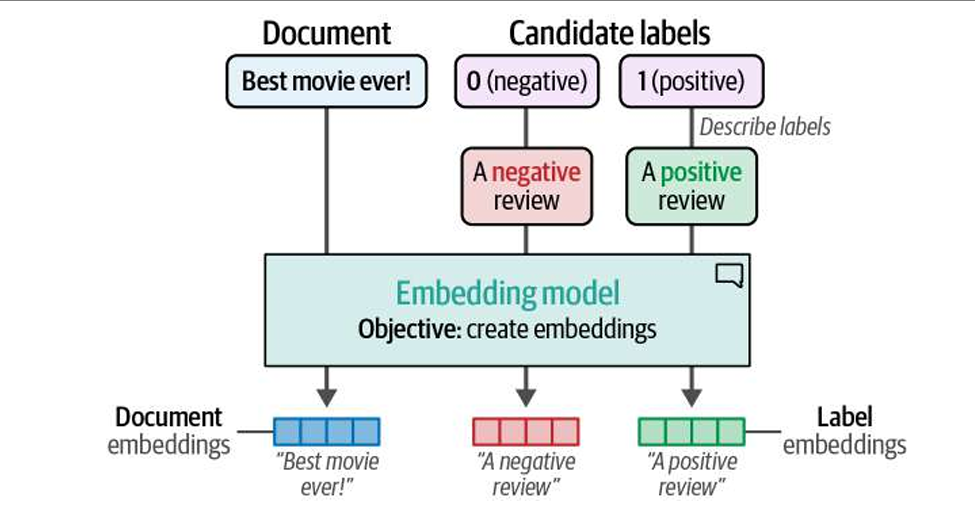


In [13]:
# Create embeddings for our labels
label_embeddings = model.encode(["A negative review",  "A positive review"])

In [14]:
from sklearn.metrics.pairwise import cosine_similarity
# Find the best matching label for each document
sim_matrix = cosine_similarity(test_embeddings, label_embeddings)
y_pred = np.argmax(sim_matrix, axis=1)

In [15]:
evaluate_performance(data["test"]["label"], y_pred)

                 precision    recall  f1-score   support

Negative Review       0.78      0.77      0.78       533
Positive Review       0.77      0.79      0.78       533

       accuracy                           0.78      1066
      macro avg       0.78      0.78      0.78      1066
   weighted avg       0.78      0.78      0.78      1066



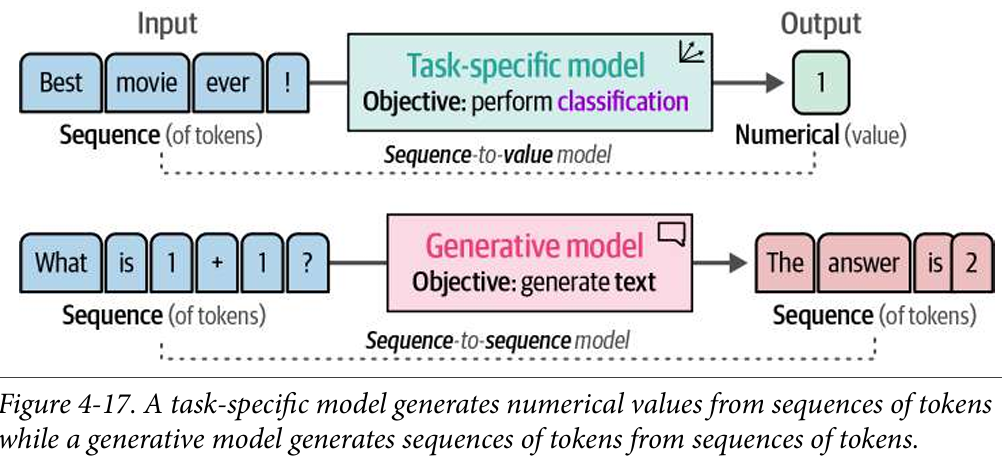

##**Using the Text-to-Text Transfer Transformer**

In [16]:
from transformers import pipeline

# Load the model
pipe2 = pipeline(
    "text-generation",
    model="google/flan-t5-large",
    device="cuda:0",
    max_new_tokens=10
)

Loading weights:   0%|          | 0/558 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.
[transformers] Passing `generation_config` together with generation-related arguments=({'max_new_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] The model 'T5ForConditionalGeneration' is not supported for text-generation. Supported models are ['PeftModelForCausalLM', 'AfmoeForCausalLM', 'ApertusForCausalLM', 'ArceeForCausalLM', 'AriaTextForCausalLM', 'BambaForCausalLM', 'BartForCausalLM', 'BertLMHeadModel', 'BertGenerationDecoder', 'BigBirdForCausalLM', 'BigBirdPegasusForCausalLM', 'BioGptForCausalLM', 'BitNetForCausalLM', 'BlenderbotForCausalLM', 'BlenderbotSmallForCa

In [17]:
from datasets import load_dataset

# Load the dataset if it's not already loaded
# data = load_dataset("cornell-movie-review-data/rotten_tomatoes")

# Prepare our data
prompt = "Is the following sentence positive or negative? "
data = data.map(lambda example : {"t5": prompt + example['text']})
print(data)

DatasetDict({
    train: Dataset({
        features: ['text', 'label', 't5'],
        num_rows: 8530
    })
    validation: Dataset({
        features: ['text', 'label', 't5'],
        num_rows: 1066
    })
    test: Dataset({
        features: ['text', 'label', 't5'],
        num_rows: 1066
    })
})


In [18]:
# Run inference
y_predd = []
for output in tqdm(pipe2(KeyDataset(data["test"], "t5")), total=len(data["test"])):
    text = output[0]["generated_text"].strip().lower()
    y_predd.append(0 if text == "negative" else 1)

100%|██████████| 1066/1066 [02:43<00:00,  6.52it/s]


In [20]:
evaluate_performance(data["test"]["label"], y_predd)

                 precision    recall  f1-score   support

Negative Review       0.00      0.00      0.00       533
Positive Review       0.50      1.00      0.67       533

       accuracy                           0.50      1066
      macro avg       0.25      0.50      0.33      1066
   weighted avg       0.25      0.50      0.33      1066

